# 02 - Análisis exploratorio de los datos por calle de Albacete
En este Notebook se realiza el análisis exploratorio de datos de los archivos de data/raw/albacete: albacete_1.sql, zz_gis_e.sql y zz_gis_v.sql.

Los objetivos principales son:
* Importar los datos, y comprobar cómo está estructurado el dataset.
* Limpiar los datos para eliminar valores nulos o erróneos que puedan afectar al análisis.
* Tratar de identificar a qué carácterísticas de accesibilidad pertenece cada variable.
* Tratar de localizar las variables candidatas a ser clases o etiquetas, y que indican el grado o puntuación de accesibilidad, u otro tipo de resultado.
* Realizar un análisis estadístico de las variables.

## Carga de datos
Los datos de Albacete contienen los scripts de creación de las tablas, así como de inserción, de MariaDB. `albacete_1.sql` contiene las tablas `zz_gis_e` y `zz_gis_v`, que también están por separado en `zz_gis_e.sql` y `zz_gis_v.sql`. Por lo que se utilizará `zz_gis_v`, que es el que contiene los datos de las calles.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
import unicodedata
import duckdb

from urban_accessibility_ml.config import (
    RAW_DATA_DIR,
    INTERIM_DATA_DIR,
)

from urban_accessibility_ml.config import RAW_DATA_DIR

ALBACETE_DIR = RAW_DATA_DIR / "albacete"
INTERIM_ALBACETE_DIR = INTERIM_DATA_DIR / "albacete"

2026-10-08 13:49:13.478 | INFO     | urban_accessibility_ml.config:<module>:11 - PROJ_ROOT path is: /home/victor-pariente/dev/tfm/tfm-urban-accessibility-ml


Se utiliza duckdb para cargar en memoria los datos, provinientes de las sentencias de `CREATE TABLE` e `INSERT`.

In [2]:
def mysql_dump_to_duckdb(text: str) -> str:
    """Convert a MySQL/MariaDB dump into SQL that DuckDB can run (CREATE TABLE and INSERT only)."""
    text = text.replace("`", '"')
    text = re.sub(r"\bint\(\d+\)", "INTEGER", text)
    text = re.sub(r"\bvarchar\(\d+\)", "VARCHAR", text)
    text = re.sub(r"\)\s*ENGINE=[^;]*;", ");", text)
    # Drop comments and session/transaction statements
    text = re.sub(r"^(--.*|/\*!.*|SET .*|START TRANSACTION;|COMMIT;)$", "", text, flags=re.M)
    return text


con = duckdb.connect()  # in-memory
for sql_file in ["zz_gis_v"]:
    con.execute(f'CREATE SCHEMA "{sql_file}"')
    con.execute(f'SET schema = \'{sql_file}\'')
    con.execute(mysql_dump_to_duckdb((ALBACETE_DIR / f"{sql_file}.sql").read_text(encoding="utf-8")))

In [3]:
# Columns and rows in the file per table_name
con.sql("""
    SELECT schema_name AS file, table_name, estimated_size AS n_rows, column_count AS n_columns
    FROM duckdb_tables()
    WHERE schema_name = 'zz_gis_v'
    ORDER BY 1, 2
""").show()

# Show all the column names and types of the duckdb table for Albacete streets
con.sql("""
    PRAGMA table_info('zz_gis_v');
""").show(max_rows=1000)

┌──────────┬────────────┬────────┬───────────┐
│   file   │ table_name │ n_rows │ n_columns │
│ varchar  │  varchar   │ int64  │   int64   │
├──────────┼────────────┼────────┼───────────┤
│ zz_gis_v │ zz_gis_v   │    916 │        95 │
└──────────┴────────────┴────────┴───────────┘

┌───────┬──────────────┬─────────┬─────────┬────────────┬─────────┐
│  cid  │     name     │  type   │ notnull │ dflt_value │   pk    │
│ int32 │   varchar    │ varchar │ boolean │  varchar   │ boolean │
├───────┼──────────────┼─────────┼─────────┼────────────┼─────────┤
│     0 │ MUNICIPIO    │ VARCHAR │ false   │ NULL       │ false   │
│     1 │ REFER        │ VARCHAR │ false   │ NULL       │ false   │
│     2 │ NUM_CALLE    │ INTEGER │ false   │ NULL       │ false   │
│     3 │ NOMBRE       │ VARCHAR │ false   │ NULL       │ false   │
│     4 │ ACCGLOBAL    │ INTEGER │ false   │ NULL       │ false   │
│     5 │ GLOBALPEND   │ INTEGER │ false   │ NULL       │ false   │
│     6 │ GLOBALANCH   │ INTEGER │ fa

Los datos continen una tabla zz_gis_v, con 916 filas y 95 columnas. Los tipos de datos son INTEGER o VARCHAR.

Transformamos a continuación las tablas en memoria, en dataframes.

In [4]:
# Albacete data as DataFrames (from the combined file)
df_alb_streets = con.sql('SELECT * FROM zz_gis_v').df()

Realizamos una rápida exploración de las primeras filas y últimas y las columnas.

In [5]:
# Show first and last 10 rows of the streets DataFrame
display(df_alb_streets.head(10))
display(df_alb_streets.tail(10))

# Exploration of the column names and types
print("Info:")
display(df_alb_streets.info())

# Describe the data
print("Description:")
display(df_alb_streets.describe())

,MUNICIPIO,REFER,NUM_CALLE,NOMBRE,ACCGLOBAL,GLOBALPEND,GLOBALANCH,GLOBALPAVIM,GLOBALCRUCES,GLOBALSEÑAL,...,TRANSPDI,FTRAPRES1,FTRAPRES2,FTRVMP1,FTRVMP2,TIPOLACT,PROPACT,PRESUP,FICHA,FICPRESUP
0,ALBACETE,HS12,10012,CALLE FELIPE II,36,50,44,31,32,25,...,36,https://drive.google.com/file/d/1SxVVrqA9iGUCP...,None,None,None,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,79500,https://drive.google.com/file/d/1Bz7z5BrZ6NppV...,https://drive.google.com/file/d/1NKIIUdJj8dX7v...
1,ALBACETE,HS11,10011,CALLE FRANCISCO JAVIER DE MOYA,36,50,44,31,32,25,...,36,https://drive.google.com/file/d/1SxVVrqA9iGUCP...,None,None,None,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,881500,https://drive.google.com/file/d/1Bz7z5BrZ6NppV...,https://drive.google.com/file/d/1ersR98VbrdUHQ...
2,ALBACETE,HS13,10013,CALLE FERNANDO III,36,50,44,31,32,25,...,36,https://drive.google.com/file/d/1SxVVrqA9iGUCP...,None,None,None,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,43000,https://drive.google.com/file/d/1Bz7z5BrZ6NppV...,https://drive.google.com/file/d/1BIpqLPRM-ksr1...
3,ALBACETE,HS14,10014,CALLE JORGE JUAN 1,36,50,44,31,32,25,...,36,https://drive.google.com/file/d/1SxVVrqA9iGUCP...,None,None,None,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,102500,https://drive.google.com/file/d/1Bz7z5BrZ6NppV...,https://drive.google.com/file/d/1hEuOLQ63ODh2Q...
4,ALBACETE,HS15,10015,CALLE JOSE CARBAJAL,36,50,44,31,32,25,...,36,https://drive.google.com/file/d/1SxVVrqA9iGUCP...,None,None,None,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,205000,https://drive.google.com/file/d/1Bz7z5BrZ6NppV...,https://drive.google.com/file/d/1Zo3x8csdwfcdd...
5,ALBACETE,HS16,10016,CALLE MUÑOZ SECA,36,50,44,31,32,25,...,36,https://drive.google.com/file/d/1SxVVrqA9iGUCP...,None,None,None,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,98000,https://drive.google.com/file/d/1Bz7z5BrZ6NppV...,https://drive.google.com/file/d/1G9rk3ynX0kH1D...
6,ALBACETE,HS17,10017,CALLE NUESTRA SEÑORA DE LA PAZ,36,50,44,31,32,25,...,36,https://drive.google.com/file/d/1SxVVrqA9iGUCP...,None,None,None,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,47500,https://drive.google.com/file/d/1Bz7z5BrZ6NppV...,https://drive.google.com/file/d/1far-u05SsOP63...
7,ALBACETE,HS18,10018,CALLE LA UNIÓN,45,100,44,44,39,34,...,0,None,None,None,None,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,152000,https://drive.google.com/file/d/11au3_5HdKfF_6...,https://drive.google.com/file/d/1erWRjKKLJq93a...
8,ALBACETE,HS19,10019,CALLE LAUREL,36,50,44,31,32,25,...,36,https://drive.google.com/file/d/1SxVVrqA9iGUCP...,None,None,None,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,211500,https://drive.google.com/file/d/1Bz7z5BrZ6NppV...,https://drive.google.com/file/d/1NajmIL8UjilRB...
9,ALBACETE,HS20,10020,CALLE MORERA,36,50,44,31,32,25,...,36,https://drive.google.com/file/d/1SxVVrqA9iGUCP...,None,None,None,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,87000,https://drive.google.com/file/d/1Bz7z5BrZ6NppV...,https://drive.google.com/file/d/1F3OwA6hmKm5FW...


,MUNICIPIO,REFER,NUM_CALLE,NOMBRE,ACCGLOBAL,GLOBALPEND,GLOBALANCH,GLOBALPAVIM,GLOBALCRUCES,GLOBALSEÑAL,...,TRANSPDI,FTRAPRES1,FTRAPRES2,FTRVMP1,FTRVMP2,TIPOLACT,PROPACT,PRESUP,FICHA,FICPRESUP
906,ALBACETE,HS5,10005,CALLE BONIFACIO SOTOS OCHANDO,36,50,44,31,32,25,...,36,https://drive.google.com/file/d/1SxVVrqA9iGUCP...,None,None,None,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,124500,https://drive.google.com/file/d/1Bz7z5BrZ6NppV...,https://drive.google.com/file/d/1csSNvYkaYYs6i...
907,ALBACETE,HS6,10006,CALLE BURGOS,36,50,44,31,32,25,...,36,https://drive.google.com/file/d/1SxVVrqA9iGUCP...,None,None,None,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,212500,https://drive.google.com/file/d/1Bz7z5BrZ6NppV...,https://drive.google.com/file/d/1D6cZIaJ7mtv3Q...
908,ALBACETE,HS7,10007,CALLE DEL AMPARO,36,50,44,31,32,25,...,36,https://drive.google.com/file/d/1SxVVrqA9iGUCP...,None,None,None,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,377500,https://drive.google.com/file/d/1Bz7z5BrZ6NppV...,https://drive.google.com/file/d/1Kj0N5_oyoCxTm...
909,ALBACETE,HS8,10008,CALLE ENEBRO,36,50,44,31,32,25,...,36,https://drive.google.com/file/d/1SxVVrqA9iGUCP...,None,None,None,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,122000,https://drive.google.com/file/d/1Bz7z5BrZ6NppV...,https://drive.google.com/file/d/1fm0_IFHo1ZkkL...
910,ALBACETE,HS9,10009,CALLE DR. BELTRÁN MATEOS,36,50,44,31,32,25,...,36,https://drive.google.com/file/d/1SxVVrqA9iGUCP...,None,None,None,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,335500,https://drive.google.com/file/d/1Bz7z5BrZ6NppV...,https://drive.google.com/file/d/1KXbtKwqXq93mP...
911,ALBACETE,HS10,10010,CALLE CRISTOBAL LOZANO,36,50,44,31,32,25,...,36,https://drive.google.com/file/d/1SxVVrqA9iGUCP...,None,None,None,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,437000,https://drive.google.com/file/d/1Bz7z5BrZ6NppV...,https://drive.google.com/file/d/1zLBCNBAZzQhlq...
912,ALBACETE,Y46,10916,CALLE TESIFONTE GALLEGO,21,100,8,8,8,8,...,0,None,None,None,None,En obras totalmente,"En obras totalmente, sin presupuesto",541500,https://drive.google.com/file/d/1ac7TYjrgu9vUL...,https://drive.google.com/file/d/18WyP_IwS6QBXE...
913,ALBACETE,Y47,10917,CALLE VEREDA DE JAÉN 2,54,100,47,77,48,24,...,36,https://drive.google.com/file/d/153BVtMgPu4lZe...,None,https://drive.google.com/file/d/1Jbe61qeY7ii_x...,https://drive.google.com/file/d/16mVw3yZsAsGUE...,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,15500,https://drive.google.com/file/d/1CcFwJFpFH3AJA...,https://drive.google.com/file/d/1oT5kLwltqQ3s1...
914,ALBACETE,Y48,10918,CALLE VEREDA DE JAÉN 3,39,100,77,15,26,15,...,21,https://drive.google.com/file/d/1WXtUIQMXMnV8B...,https://drive.google.com/file/d/1Pz3Qi2_xjOftD...,https://drive.google.com/file/d/1cXHmVfrb3RDMk...,https://drive.google.com/file/d/1TIo38Sz3yqPxm...,Tráfico Diferenciado,Mejora en Vía existente: Tráfico Diferenciado,737000,https://drive.google.com/file/d/1YGyPd9tkbFF5z...,https://drive.google.com/file/d/1uK_vkTAS5Etd-...
915,ALBACETE,Y49,10919,CALLE ZAPATEROS 2,60,100,77,77,86,21,...,0,None,None,None,None,Peatonal,Mejora en Vía existente: Peatonal,3500,https://drive.google.com/file/d/1aG5Kzs235-VoQ...,https://drive.google.com/file/d/1KaohiHSmIxrMq...


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 95 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   MUNICIPIO     916 non-null    object
 1   REFER         916 non-null    object
 2   NUM_CALLE     916 non-null    int32 
 3   NOMBRE        916 non-null    object
 4   ACCGLOBAL     916 non-null    int32 
 5   GLOBALPEND    916 non-null    int32 
 6   GLOBALANCH    916 non-null    int32 
 7   GLOBALPAVIM   916 non-null    int32 
 8   GLOBALCRUCES  916 non-null    int32 
 9   GLOBALSEÑAL   916 non-null    int32 
 10  GLOBALILUM    916 non-null    int32 
 11  GLOBALMOBI    916 non-null    int32 
 12  GLOBALTRANSP  916 non-null    int32 
 13  GLOBALSR      916 non-null    int32 
 14  GLOBALMR      916 non-null    int32 
 15  GLOBALDV      916 non-null    int32 
 16  GLOBALHA      916 non-null    int32 
 17  GLOBALDI      916 non-null    int32 
 18  FGLOBAL1      894 non-null    object
 19  FG

None

Description:


,NUM_CALLE,ACCGLOBAL,GLOBALPEND,GLOBALANCH,GLOBALPAVIM,GLOBALCRUCES,GLOBALSEÑAL,GLOBALILUM,GLOBALMOBI,GLOBALTRANSP,...,MOBILIARMR,MOBILIARDV,MOBILIARHA,MOBILIARDI,TRANSPSR,TRANSPMR,TRANSPDV,TRANSPHA,TRANSPDI,PRESUP
count,916.000000,916.000000,916.000000,916.000000,916.000000,916.000000,916.000000,916.000000,916.000000,916.000000,...,916.000000,916.000000,916.000000,916.000000,916.000000,916.000000,916.000000,916.000000,916.000000,9.160000e+02
mean,10459.457424,43.317686,87.696507,47.609170,41.319869,38.930131,29.256550,30.521834,34.477074,21.427948,...,39.639738,28.078603,45.111354,26.504367,19.497817,25.930131,19.652838,26.468341,15.818777,2.684683e+05
std,265.568625,11.544760,21.819919,20.060784,20.077644,16.757073,10.993029,10.653744,14.140610,18.208874,...,18.159196,13.522874,15.666770,10.583985,17.370379,22.069526,17.127219,22.100419,13.506927,1.094391e+06
min,10001.000000,19.000000,10.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,0.000000,...,10.000000,8.000000,9.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,10229.750000,36.000000,100.000000,34.000000,25.000000,26.000000,23.000000,24.000000,25.000000,0.000000,...,26.750000,17.000000,36.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.587500e+04
50%,10459.500000,42.000000,100.000000,44.000000,35.000000,35.000000,28.000000,29.000000,31.000000,25.000000,...,36.000000,26.000000,42.000000,24.000000,18.000000,31.000000,17.000000,36.000000,18.000000,1.230000e+05
75%,10688.250000,52.000000,100.000000,67.000000,51.000000,48.000000,33.000000,34.000000,41.250000,35.000000,...,48.000000,34.000000,57.000000,33.000000,36.000000,41.000000,30.000000,40.000000,27.000000,2.710000e+05
max,10919.000000,77.000000,100.000000,86.000000,77.000000,86.000000,67.000000,77.000000,77.000000,52.000000,...,93.000000,76.000000,81.000000,54.000000,54.000000,62.000000,51.000000,63.000000,39.000000,3.143800e+07


In [6]:
# Show number of columns per type
df_alb_streets.dtypes.value_counts()

int32     56
object    39
Name: count, dtype: int64


Tras una primera exploración de los datos, se puede observar:
* El conjunto de datos tiene un total de 916 filas y 95 columnas.
* Se pueden observar un total de 56 columnas de tipo int32, el resto son de tipo object, aunque se recuerda que en la base de datos estaban indicadas como String.
* La columna 51 no tiene nombre, tiene todos los valores nulos, y es la única con tipo de datos float64.

En cuanto a las primeras columnas:
* La columna MUNICIPIO es el nombre del municipio sobre el que se tiene datos. Parece que todos los valores se corresponden con ALBACETE.
* La columna REFER actúa como índice de la tabla, y tiene el formato (L)LCC, donde C es una cifra y L es una letra. Por ejemplo: Y49.
* La columna NUM_CALLE contiene un ídentificador del número de la calle. Hay que comprobar cuál es la relación entre REFER y NUM_CALLE.
* La columna ACCGLOBAL contiene un valor numérico, entre 19 y 77, y parece indicar la puntuación de accesibilidad global de la calle.
* Hay varias columnas GLOBAL (PEND, ANCH, PAVIM, CRUCES... y SR, MR, DV, HA, DI), toman valores del 0 al 100, y parecen similares a las del conjunto de datos de Algeciras.
* Hay dos columnas FGLOBAL1 y FGLOBAL2 que son cadena de caracteres, y contienen un enlace a Google Drive, por lo que parece que F significa foto. FGLOBAL2 tiene más valores nulos a primera vista (solo 651 tienen este campo relleno).
* Hay varias columnas para PENDIENTE, PAVIMENTO, CRUCES, ANCHURA, ... con los sufijos SR, MR, DV, HA y DI.
* También hay columnas con prefijo F (fotos), para cada una de esas dimensiones (PENDIENTE, PAVIMENTO, CRUCES, ANCHURA, SEÑALIZ, ILUMIN, MOBILIAR, TRANSP), como FSEÑALIZ1 y FSEÑALIZ2. Hay algunas columnas que se corresponden con las fotos de una de las dimensiones, pero con distintos nombres, como: FANCHBVAR1 o FCRSEMF1.
* TIPOLACT contiene las categorias de tipo de vía (como "Tráfico Diferenciado"). Similar a la variable TIPOLOGÍA de Algeciras.
* PROPACT contiene la propuesta de actuación (como "Mejora en Vía existente: Tráfico Diferenciado"). Similar a la variable PROPUESTA de Algeciras.
* PRESUP contiene el presupuesto en euros, entre 0 y 31.438.000 €. Similar a la variable PRESUPUESTO de Algecias.
* FICHA y FICPRESUP contienen enlaces a Google Drive, intuyendo que se tratan de la ficha del informe de la calle, así como la ficha del presupuesto para la reparación o mejora.

## Limpieza de datos

En primer lugar, vamos a eliminar del conjunto de datos todas las variables que sean de fotos, puesto que no se van a utilizar en este análisis exploratorio (podrían servir en el futuro para comprobar qué tipo de decisiones se han tomado para indicar los valores de accesibilidad).

In [7]:
# Drop the columns containing photo links or Google Drive links (all starting with F, or FICHA y FICPRESUP)
# Note: there are not any other column starting with F affected by this operation
cols_to_drop = [col for col in df_alb_streets.columns if col.startswith('F')]
df_alb_streets_cleaned = df_alb_streets.drop(columns=cols_to_drop)

# Show the cleaned DataFrame columns
display(df_alb_streets_cleaned.columns)
display(df_alb_streets_cleaned.shape)

Index(['MUNICIPIO', 'REFER', 'NUM_CALLE', 'NOMBRE', 'ACCGLOBAL', 'GLOBALPEND',
       'GLOBALANCH', 'GLOBALPAVIM', 'GLOBALCRUCES', 'GLOBALSEÑAL',
       'GLOBALILUM', 'GLOBALMOBI', 'GLOBALTRANSP', 'GLOBALSR', 'GLOBALMR',
       'GLOBALDV', 'GLOBALHA', 'GLOBALDI', 'PENDIENTESR', 'PENDIENTEMR',
       'PENDIENTEDV', 'PENDIENTEHA', 'PENDIENTEDI', 'ANCHURASR', 'ANCHURAMR',
       'ANCHURADV', 'ANCHURAHA', 'ANCHURADI', 'PAVIMENTOSR', 'PAVIMENTOMR',
       'PAVIMENTODV', 'PAVIMENTOHA', 'PAVIMENTODI', 'CRUCESSR', 'CRUCESMR',
       'CRUCESDV', 'CRUCESHA', 'CRUCESDI', 'SEÑALIZSR', 'SEÑALIZMR',
       'SEÑALIZDV', 'SEÑALIZHA', 'SEÑALIZDI', 'ILUMINSR', 'ILUMINMR',
       'ILUMINDV', 'ILUMINHA', 'ILUMINDI', 'MOBILIARSR', 'MOBILIARMR',
       'MOBILIARDV', 'MOBILIARHA', 'MOBILIARDI', 'TRANSPSR', 'TRANSPMR',
       'TRANSPDV', 'TRANSPHA', 'TRANSPDI', 'TIPOLACT', 'PROPACT', 'PRESUP'],
      dtype='object')

(916, 61)

Nos quedamos con 916 filas y 61 columnas.

Vamos a comprobar si hay duplicados.

In [8]:
# Check if there are duplicates
print("Number of duplicate rows:")
display(df_alb_streets_cleaned.duplicated().sum())

# Check if there are street names duplicates
print("Number of duplicate street names:")
display(df_alb_streets_cleaned['NOMBRE'].duplicated().sum())

# Check if there are REFER or NUM_CALLE duplicates
print("Number of duplicate REFER values:")
display(df_alb_streets_cleaned['REFER'].duplicated().sum())

print("Number of duplicate NUM_CALLE values:")
display(df_alb_streets_cleaned['NUM_CALLE'].duplicated().sum())


Number of duplicate rows:


np.int64(0)

Number of duplicate street names:


np.int64(10)

Number of duplicate REFER values:


np.int64(0)

Number of duplicate NUM_CALLE values:


np.int64(0)

Se ha comprobado que no existe ningún duplicado. Comprobamos el número de nulos por columna.

In [9]:
# Check nulls per column
print("Number of nulls per column:")
display(df_alb_streets_cleaned.isnull().sum())

Number of nulls per column:


MUNICIPIO    0
REFER        0
NUM_CALLE    0
NOMBRE       0
ACCGLOBAL    0
            ..
TRANSPHA     0
TRANSPDI     0
TIPOLACT     0
PROPACT      0
PRESUP       0
Length: 61, dtype: int64

No hay ninguna fila con valores nulos para ninguna columna.

Comprobamos cuántos municipios hay, por si hay que filtrar alguno que no sea ALBACETE.

In [10]:
# Verify how many unique values are for MUNICIPIO column
print("Number of unique MUNICIPIO values:")
display(df_alb_streets_cleaned['MUNICIPIO'].nunique())

# Show the unique values for MUNICIPIO column
print("Unique MUNICIPIO values:")
display(df_alb_streets_cleaned['MUNICIPIO'].unique())

Number of unique MUNICIPIO values:


1

Unique MUNICIPIO values:


array(['ALBACETE'], dtype=object)

Todos los datos son de Albacete, por lo que eliminamos esta columna, que ya no sirve para el análisis.

In [11]:
# Drop MUNICIPIO column 
df_alb_streets_cleaned = df_alb_streets_cleaned.drop(columns=['MUNICIPIO'])
print("MUNICIPIO column dropped.")

MUNICIPIO column dropped.


Comprobamos si hay alguna REFER o NUM_CALLE repetida en alguna de las filas.

In [12]:
# Check if REFER or NUM_CALLE contains a single value repeated in several rows, or if the values are unique per row
print("Number of unique REFER values:")
display(df_alb_streets_cleaned['REFER'].nunique())

print("Number of unique NUM_CALLE values:")
display(df_alb_streets_cleaned['NUM_CALLE'].nunique())

Number of unique REFER values:


916

Number of unique NUM_CALLE values:


916

#### Nombres de calle repetidos o parecidos

Aunque no hay filas duplicadas, sí que se han identificado nombres de calle repetidos. Se evalúan tres casos: o el nombre es completamente igual, o son iguales cuando se eliminan espacios, tildes o se normaliza a mayúsculas; o que el nombre sea igual, quitando el número de tramo del final (por ejemplo, `CALLE JORGE JUAN 1` y `CALLE JORGE JUAN 2`).

Primero se muestran las calles con el nombre exactamente repetido:

In [13]:
# Streets with the exact same name
display(df_alb_streets_cleaned[df_alb_streets_cleaned['NOMBRE'].duplicated(keep=False)]
        .sort_values('NOMBRE')[['NOMBRE', 'REFER', 'NUM_CALLE', 'TIPOLACT', 'ACCGLOBAL', 'PRESUP']])

,NOMBRE,REFER,NUM_CALLE,TIPOLACT,ACCGLOBAL,PRESUP
387,CALLE BONIFACIO SOTOS OCHANDO,MI3,10398,Tráfico Diferenciado,38,397500
906,CALLE BONIFACIO SOTOS OCHANDO,HS5,10005,Tráfico Diferenciado,36,124500
131,CALLE DIONISIO GUARDIOLA,CA40,10142,Tráfico Diferenciado,44,140500
856,CALLE DIONISIO GUARDIOLA,VC33,10870,Tráfico Diferenciado,54,430500
474,CALLE LUGO 2,PL24,10486,Peatonal,44,62000
468,CALLE LUGO 2,PL18,10480,Tráfico Diferenciado,37,70000
633,CALLE MEJICO 01,SM5,10645,Tráfico Diferenciado,47,230000
450,CALLE MEJICO 01,PM22,10462,Tráfico Diferenciado,41,261000
5,CALLE MUÑOZ SECA,HS16,10016,Tráfico Diferenciado,36,98000
418,CALLE MUÑOZ SECA,PQ7,10430,Tráfico Diferenciado,30,310000


A continuación se comparan las tres condiciones, y se muestran los grupos de calles con el mismo nombre base.

In [14]:
# Streets with a repeated name at three levels: identical, identical after normalizing, and identical base name (without the section number)
def normalize_name(name):
    name = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode().upper()
    return re.sub(r'\s+', ' ', name).strip()

def base_name(name):
    return re.sub(r'\s+\d+$', '', normalize_name(name))

names = df_alb_streets_cleaned['NOMBRE']
display(pd.Series({
    'Nombre idéntico': names.duplicated(keep=False).sum(),
    'Nombre idéntico al normalizar': names.map(normalize_name).duplicated(keep=False).sum(),
    'Mismo nombre base (sin el número de tramo)': names.map(base_name).duplicated(keep=False).sum(),
}, name='Calles con el nombre repetido').to_frame())

# Groups of streets with the same base name
base_names = names.map(base_name)
groups = (base_names[base_names.duplicated(keep=False)].value_counts().rename_axis('nombre_base').reset_index(name='calles')
          .sort_values(['calles', 'nombre_base'], ascending=[False, True]))
print(f"Grupos de calles con el mismo nombre base: {len(groups)}")
display(groups.head(10).set_index('nombre_base'))

,Calles con el nombre repetido
Nombre idéntico,20
Nombre idéntico al normalizar,22
Mismo nombre base (sin el número de tramo),324


Grupos de calles con el mismo nombre base: 141


,calles
nombre_base,
AVENIDA DE LA MANCHA,4
CALLE AMANECER,4
CALLE FERNANDO POO,4
CALLE HERMANOS QUINTERO,4
CALLE JORGE JUAN,4
CALLE MEJICO,4
CALLE PADRE ROMANO,4
AVENIDA DEL ARTE,3
CALLE ALCARAZ,3


Por último, hay nombres que empiezan por OTRO, que parecen espacios que no son calles (parques, jardines...), todos considerados como peatonales:

In [15]:
# Names that start with OTRO
display(df_alb_streets_cleaned[df_alb_streets_cleaned['NOMBRE'].str.upper().str.startswith('OTRO')][['REFER', 'NOMBRE', 'TIPOLACT', 'PRESUP']])

,REFER,NOMBRE,TIPOLACT,PRESUP
88,CÑ69,OTRO JARDÍN DE LOS PEQUEÑOS OFICIOS,Peatonal,312000
89,CÑ70,OTRO PARQUE CALLE SATURNINO CALLEJA,Peatonal,424500
90,CÑ71,OTRO PARQUE DE LOS CUENTOS,Peatonal,518000
348,MD8,OTRO JARDÍN DE LOS SCOUTS 01,Peatonal,246000
349,MD9,OTRO JARDÍN DE LOS SCOUTS 02,Peatonal,186500
358,MD18,OTRO PARQUE CARRETERA DE VALENCIA 01,Peatonal,673000
359,MD19,OTRO PARQUE CARRETERA DE VALENCIA 02,Peatonal,1985500
360,MD20,OTRO PARQUE FÉLIX RODRIGUEZ DE LA FUENTE 01,Peatonal,822500
549,SA42,OTRO DEL TRÁNSITO,Peatonal,134000
550,SA43,OTRO DEL III CENTENARIO,Peatonal,348000


#### Zona de la calle

La columna REFER tiene el formato letras y número (por ejemplo, `FT23`). Algunos nombres repetidos terminan con esas mismas letras (como `CALLE JUAN DE AUSTRIA FT` y `CALLE JUAN DE AUSTRIA FR`), por lo que se puede intuir que las letras identifican una zona (posiblemente el barrio, como la columna Barriada de Algeciras).

Para comprobarlo, se extraen las letras de REFER, se cuenta el número de calles de cada grupo, y se comprueba si los nombres repetidos están en grupos de letras distintos.

In [16]:
# Letters of REFER, number of streets per group of letters, and the names repeated in different groups
zone = df_alb_streets_cleaned['REFER'].str.extract(r'^([A-ZÑ]+)')[0]
print(f"Grupos de letras distintos: {zone.nunique()}")
display(zone.value_counts().to_frame('calles').T)

repeated = df_alb_streets_cleaned[df_alb_streets_cleaned['NOMBRE'].duplicated(keep=False)].assign(zona=zone)
zones_per_name = repeated.groupby('NOMBRE')['zona'].nunique()
print(f"Nombres repetidos: {len(zones_per_name)}, de los cuales {(zones_per_name > 1).sum()} están en grupos de letras distintos")
ends_with_zone = df_alb_streets_cleaned['NOMBRE'].str.upper().str.extract(r'\s([A-ZÑ]{2})$')[0] == zone
print(f"Nombres que terminan con las letras de su REFER: {ends_with_zone.sum()}")
display(df_alb_streets_cleaned[ends_with_zone][['REFER', 'NOMBRE']])

Grupos de letras distintos: 27


,CÑ,CA,SM,Y,UV,MD,SA,FR,SP,X,...,ES,ST,VC,PM,MI,FE,PQ,HF,LL,PA
calles,72,65,60,49,45,44,43,42,38,38,...,29,28,24,23,19,18,17,17,15,7


Nombres repetidos: 10, de los cuales 9 están en grupos de letras distintos
Nombres que terminan con las letras de su REFER: 6


,REFER,NOMBRE
187,FT23,CALLE JUAN DE AUSTRIA FT
196,FT2,CALLE ARCIPRESTE GÁLVEZ FT
270,FR36,CALLE JUAN DE AUSTRIA FR
552,SA45,CALLE FEDERICO GARCÍA LORCA SA
716,ST24,CALLE VEREDA DE JAÉN ST
796,UV43,CALLE ARADO UV


Como las letras de REFER distinguen calles con el mismo nombre, se crea la variable ZONA a partir de ellas (no se sabe el nombre del barrio al que corresponde cada una, a diferencia de Algeciras).

In [17]:
# Create the ZONA variable from the letters of REFER
df_alb_streets_cleaned['ZONA'] = df_alb_streets_cleaned['REFER'].str.extract(r'^([A-ZÑ]+)')[0]
print(f"Columna ZONA creada, con {df_alb_streets_cleaned['ZONA'].nunique()} valores distintos.")

Columna ZONA creada, con 27 valores distintos.


In [18]:
# Show table info, and different values per category (excluding REFER, NUM_CALLE or NOMBRE)
display(df_alb_streets_cleaned.info())

# Show different values per category
for column in df_alb_streets_cleaned.select_dtypes(include=['object']).columns:
    if column not in ['REFER', 'NUM_CALLE', 'NOMBRE']:
        print(f"Unique values for column {column}:")
        display(df_alb_streets_cleaned[column].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 61 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   REFER         916 non-null    object
 1   NUM_CALLE     916 non-null    int32 
 2   NOMBRE        916 non-null    object
 3   ACCGLOBAL     916 non-null    int32 
 4   GLOBALPEND    916 non-null    int32 
 5   GLOBALANCH    916 non-null    int32 
 6   GLOBALPAVIM   916 non-null    int32 
 7   GLOBALCRUCES  916 non-null    int32 
 8   GLOBALSEÑAL   916 non-null    int32 
 9   GLOBALILUM    916 non-null    int32 
 10  GLOBALMOBI    916 non-null    int32 
 11  GLOBALTRANSP  916 non-null    int32 
 12  GLOBALSR      916 non-null    int32 
 13  GLOBALMR      916 non-null    int32 
 14  GLOBALDV      916 non-null    int32 
 15  GLOBALHA      916 non-null    int32 
 16  GLOBALDI      916 non-null    int32 
 17  PENDIENTESR   916 non-null    int32 
 18  PENDIENTEMR   916 non-null    int32 
 19  PENDIENT

None

Unique values for column TIPOLACT:


array(['Tráfico Diferenciado', 'Plaza', 'Bulevar', 'Peatonal',
       'Plataforma', 'Peatonal Residentes / Emergencias',
       'En obras parcialmente', 'En obras totalmente'], dtype=object)

Unique values for column PROPACT:


array(['Mejora en Vía existente: Tráfico Diferenciado',
       'Mejora en Vía existente: Peatonal',
       'Cambio de Tipología: Plataforma',
       'Mejora en Vía existente: Plataforma',
       'En obras totalmente, sin presupuesto'], dtype=object)

Unique values for column ZONA:


array(['HS', 'CÑ', 'CA', 'ES', 'FT', 'FE', 'FR', 'HF', 'ID', 'LL', 'MD',
       'MI', 'PA', 'PQ', 'PM', 'PL', 'PS', 'SA', 'X', 'SP', 'SM', 'ST',
       'SE', 'UV', 'VE', 'VC', 'Y'], dtype=object)

Una vez comprobado que todos los datos son de calles de Albacete, que no hay ninguna fila con nulos, y que no existen duplicados, se procede a realizar el análisis univariante, después de transformar los tipos de datos.

## Transformación de tipo de datos

Vamos a realizar la transformación de los datos de tipo object a string, o categorías, según el caso:
* Datos String: NOMBRE, REFER, NUM_CALLE.
* Datos categóricos: TIPOLACT y PROPACT.

In [19]:
# Transform categorical columns to categories (excluding REFER, NUM_CALLE or NOMBRE)
for column in df_alb_streets_cleaned.select_dtypes(include=['object']).columns:
    if column not in ['REFER', 'NUM_CALLE', 'NOMBRE']:
        df_alb_streets_cleaned[column] = df_alb_streets_cleaned[column].astype('category')
        print(f"Transformed column {column} into categorical type.")

Transformed column TIPOLACT into categorical type.
Transformed column PROPACT into categorical type.
Transformed column ZONA into categorical type.


#### Nombre base y tramo de la calle

Algunas calles están divididas en tramos, que se identifican con un número al final del nombre (por ejemplo, `CALLE JORGE JUAN 1` y `CALLE JORGE JUAN 2`). A partir del nombre se crean dos variables:
* `NOMBRE_BASE`: el nombre normalizado (en mayúsculas, sin tildes) y sin el número de tramo.
* `TRAMO`: el número de tramo (`01` es el tramo 1). Si el nombre no termina en número, el tramo es nulo.

In [20]:
# Base name and section (tramo) of the streets: the section is the number at the end of the name (01 is 1)
df_alb_streets_cleaned['NOMBRE_BASE'] = df_alb_streets_cleaned['NOMBRE'].map(base_name)
df_alb_streets_cleaned['TRAMO'] = (df_alb_streets_cleaned['NOMBRE'].map(normalize_name).str.extract(r'\s(\d+)$')[0]
                                   .astype('Int64'))
display(df_alb_streets_cleaned['TRAMO'].value_counts(dropna=False).sort_index().to_frame('calles'))

,calles
TRAMO,
1,125
2,139
3,32
4,6
7,1
10,1
<NA>,612


## Análisis univariante

### Variables categóricas
A continuación analizaremos y visualizaremos los diferentes tipos y la frecuencia de las variables categóricas: TIPOLACT y PROPACT. 

In [21]:
def plot_category_frequencies(df, col, top_n=10):
    """Show the absolute and relative frequencies of a categorical column as a table and a horizontal bar chart.

    Only the top_n categories are shown; the remaining ones are grouped in a single 'Others' row.
    """
    counts = df[col].value_counts()
    counts = counts[counts > 0]
    counts.index = counts.index.astype('string')
    grouped = len(counts) > top_n
    if grouped:
        rest = counts.iloc[top_n:]
        counts = pd.concat([counts.iloc[:top_n], pd.Series({f'Others ({len(rest)} categories)': rest.sum()})])
    freq = pd.DataFrame({'count': counts, 'percentage': (counts / counts.sum() * 100).round(1)})
    display(freq)

    # Horizontal bars keep long labels readable; height grows with the number of bars
    plt.figure(figsize=(10, max(3, 0.35 * len(freq))))
    ax = sns.barplot(x=freq['percentage'], y=freq.index, orient='h', color='steelblue')
    if grouped:
        ax.containers[0][-1].set_color('lightgray')
    ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
    ax.set(title=f'Frecuencias relativas de {col}', xlabel='Porcentaje de calles (%)', ylabel='')
    plt.tight_layout()
    plt.show()

,count,percentage
TIPOLACT,,
Tráfico Diferenciado,659,71.9
Peatonal,154,16.8
Plataforma,56,6.1
Peatonal Residentes / Emergencias,18,2.0
Plaza,18,2.0
Bulevar,6,0.7
En obras parcialmente,3,0.3
En obras totalmente,2,0.2


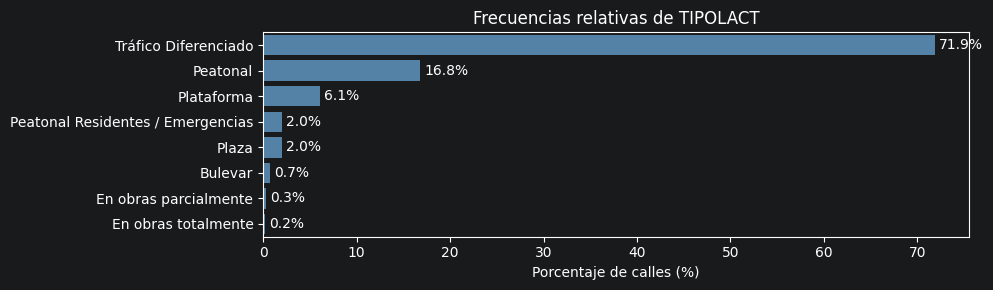

In [22]:
plot_category_frequencies(df_alb_streets_cleaned, 'TIPOLACT')

La mayoría de las calles tienen el tráfico diferenciado (un 71,9%), seguido de peatonal (16,8%) o plataforma (6,1%).

Hay dos categorías en obras (con porcentajes mínimos), para hacer un total de 8 categorías diferente de tipología de calle.

,count,percentage
PROPACT,,
Mejora en Vía existente: Tráfico Diferenciado,520,56.8
Mejora en Vía existente: Peatonal,186,20.3
Cambio de Tipología: Plataforma,151,16.5
Mejora en Vía existente: Plataforma,57,6.2
"En obras totalmente, sin presupuesto",2,0.2


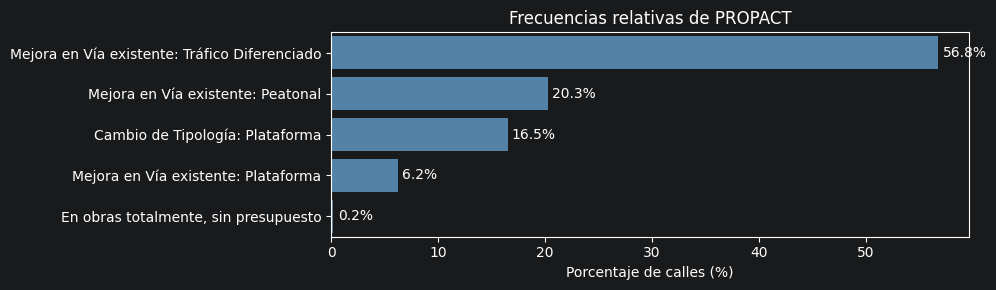

In [23]:
plot_category_frequencies(df_alb_streets_cleaned, 'PROPACT')

La columna PROPACT contiene 5 diferentes tipos de propuesta, con la de "Mejora en vía existente: tráfico diferenciado" con la mayoría de las calles (56,8%).

Las propuestas contienen dos informaciones: el tipo de propuesta ("Mejora en vía existente", "Cambio de tipología", o "En obras totalmente"), así como el tipo de vía.

Las mejoras en vía existente suman un total del 83,3% de las calles, mientras que el cambio de tipología únicamente en el 16,5%. Las calles en obras totalmente tienen un porcentaje residual (0,2%).

### Variable continua presupuesto

Vamos a analizar la columna PRESUPUESTO:

count    9.160000e+02
mean     2.684683e+05
std      1.094391e+06
min      0.000000e+00
25%      5.587500e+04
50%      1.230000e+05
75%      2.710000e+05
max      3.143800e+07
Name: PRESUP, dtype: float64

/home/victor-pariente/dev/tfm/tfm-urban-accessibility-ml/.venv/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


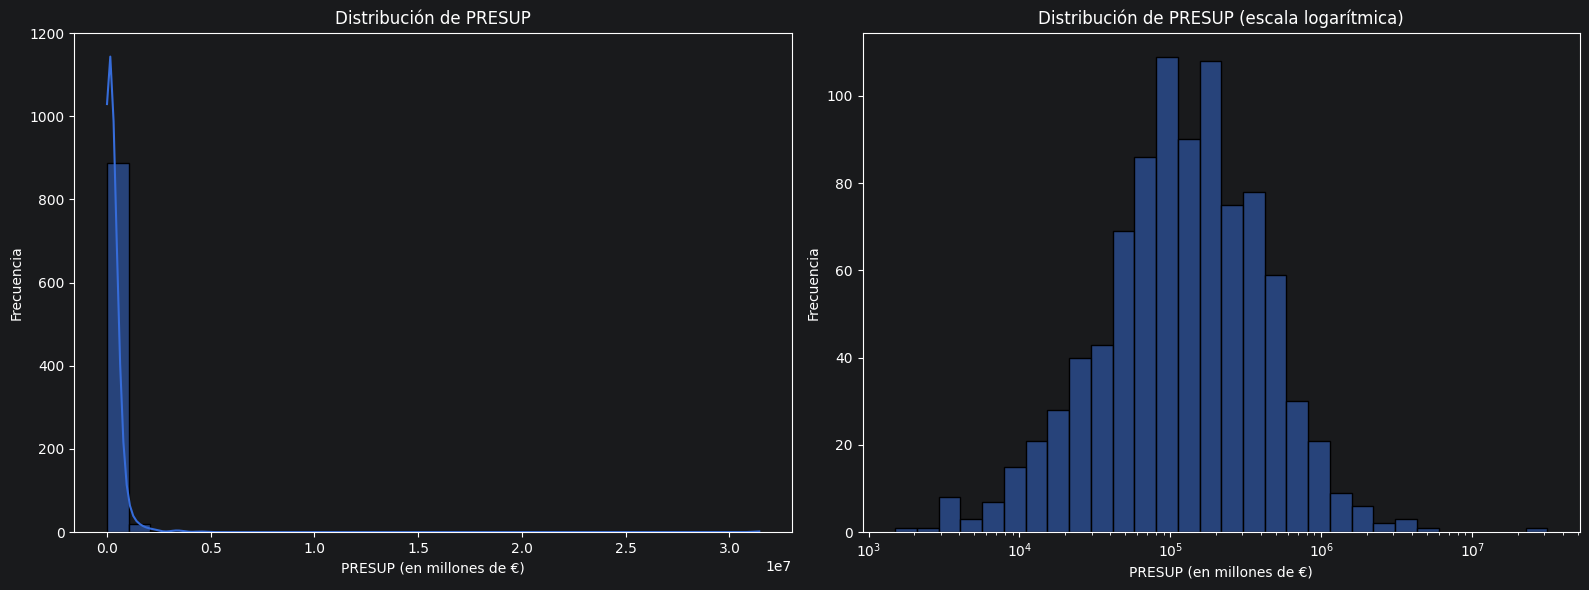

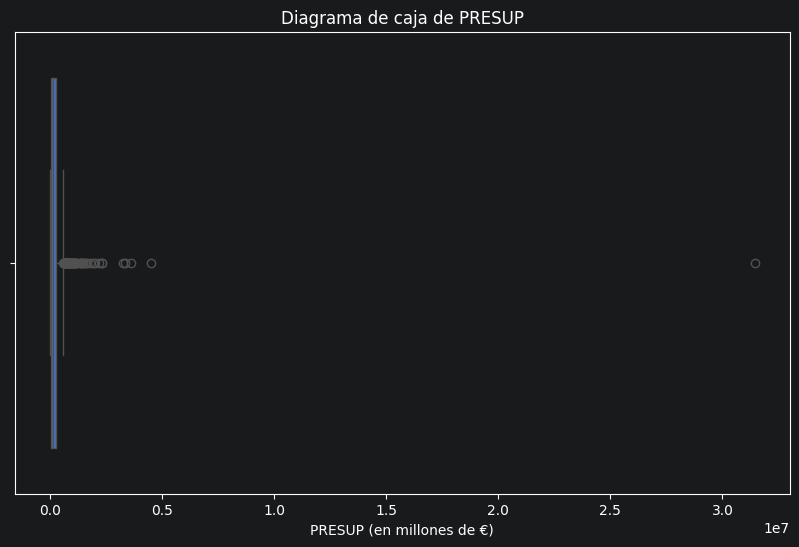

In [24]:
# Analyze column continuous 'PRESUPUESTO'
display(df_alb_streets_cleaned['PRESUP'].describe())

# Visualize the distribution of 'PRESUPUESTO' on the raw scale and on a log scale
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df_alb_streets_cleaned['PRESUP'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribución de PRESUP')
sns.histplot(df_alb_streets_cleaned['PRESUP'], bins=30, kde=True, log_scale=True, ax=axes[1])
axes[1].set_title('Distribución de PRESUP (escala logarítmica)')
for ax in axes:
    ax.set_xlabel('PRESUP (en millones de €)')
    ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Box plot of 'PRESUP'
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_alb_streets_cleaned['PRESUP'])
plt.title('Diagrama de caja de PRESUP')
plt.xlabel('PRESUP (en millones de €)')
plt.show()

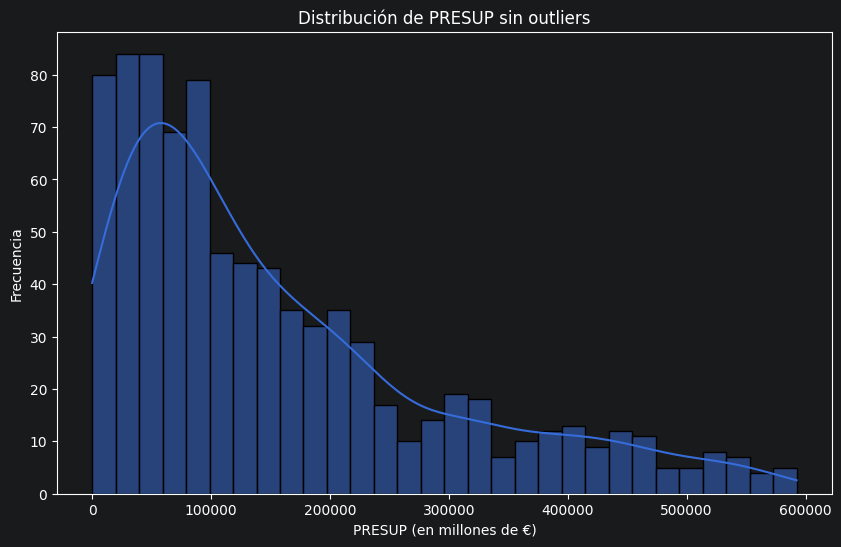

In [25]:
# Show frequency for 'PRESUP' without outliers
Q1 = df_alb_streets_cleaned['PRESUP'].quantile(0.25)
Q3 = df_alb_streets_cleaned['PRESUP'].quantile(0.75)
IQR = Q3 - Q1
df_alb_streets_no_outliers = df_alb_streets_cleaned[(df_alb_streets_cleaned['PRESUP'] >= Q1 - 1.5 * IQR) & (df_alb_streets_cleaned['PRESUP'] <= Q3 + 1.5 * IQR)]

# Plot frequency of 'PRESUP' without outliers
plt.figure(figsize=(10, 6))
sns.histplot(df_alb_streets_no_outliers['PRESUP'], bins=30, kde=True)
plt.title('Distribución de PRESUP sin outliers')
plt.xlabel('PRESUP (en millones de €)')
plt.ylabel('Frecuencia')
plt.show()

Se puede comprobar que la distribución de prespuesto es muy asimétrica a la derecha ().

La mayoría de calles (el 75%) tiene un presupuesto de reparación asignado menor a 271.000 €, con una mediana de 123.000 €.
La distribución es asimétrica a la derecha (la media es mucho más elevada que la mediana, 268.468,34€).

Esto implica que algunas pocas calles concentran la mayoría del presupuesto. Mostramos las que tienen mayor presupuesto asignado.

In [26]:
# Show streets sort by 'PRESUP' descending (top 10)
df_alb_streets_cleaned[['NOMBRE', 'PRESUP']].sort_values(by='PRESUP', ascending=False).head(10)


,NOMBRE,PRESUP
354,AVENIDA ELEAZAR HUERTA,31438000
567,AVENIDA DE LA MANCHA 3,4501500
579,AVENIDA GREGORIO ARCOS,3589000
578,AVENIDA ESPAÑA,3328000
565,PASEO DE LA CUBA 1,3261500
551,OTRO LINEAL,2334000
26,AVENIDA EMILIA PARDO BAZÁN 1,2332500
576,CARRETERA DE VALENCIA 2,2179000
359,OTRO PARQUE CARRETERA DE VALENCIA 02,1985500
87,CALLE VIRGEN DEL PILAR 2,1902000


Se puede comprobar que parecen ser calles grandes (avenidas, paseos...). Destaca la Avenida Eleazar Huerta, con 31 millones de euros.

### Variables de puntuación de accesibilidad

En primer lugar, tenemos 5 puntuaciones para cada una de las siguientes dimensiones:
* PENDIENTE
* ANCHURA
* PAVIMENTO
* CRUCES
* SEÑALIZ
* ILUMIN
* MOBILIAR
* TRANSP (esta solo aparece en los datos de Albacete, pero no en Algeciras).

Para cada una de esas dimensiones, hay 5 valores, según el tipo de diversidad funcional, y que se ponen como sufijos (por ejemplo, PENDIENTEMR):
* SR: se intuye que silla de ruedas.
* MR: se intuye que es movilidad reducida.
* DV: se intuye que es discapacidad visual.
* HA: se intuye que es hipoacusia, problemas de audición.
* DI: se intuye que es intelectual/cognitiva.

Como nota, parece que la diferencia con Algeciras es que hay 2 categorías más. La funcional de Algeciras son aquí SR y MR, mientras que la sensorial DV y HA, según se intuye.

También hay una serie de puntuaciones globales, tanto por dimensión, como por diversidad funcional:
* Dimensión: GLOBALANCH, GLOBALPAVIM, GLOBALCRUCES, GLOBALSEÑAL, GLOBALILUM, GLOBALMOBI, GLOBALTRANSP intuimos que son las medias de todos los valores de cada dimensión.
* Diversidad funcional: GLOBALSR, GLOBALMR, GLOBALDV, GLOBALHA, GLOBALDI, que intuimos que son las medias agrupadas por diversidad funcional, en todas las categorías.

Finalmente, tenemos la variable ACCGLOBAL, que intuimos que es la media de todos los valores de dimensiones y diversidad funcional.

Vamos a proceder con un análisis de estas variables, para poder verificar estas hipótesis.

Empezamos comprobando que las variables GLOBAL<DIMENSION> son la media de las dimensiones.
   

#### Puntuaciones GLOBAL por dimensión y por tipo de diversidad

In [27]:
# Dict with each dimension (PENDIENTE, ANCHURA, PAVIMENTO, CRUCES, SEÑALIZ, ILUMIN, MOBILIAR) and for values, all the columns that they have (e.g., PENDIENTE: [PENDIENTEXXX, PENDIENTEXXX], ANCHURA: [ANCHOXXX, ANCHOXXX], etc.), and what is the GLOBALXXXX column they have.
dimensions_dict = {
    "PENDIENTE": {
        "columns": ["PENDIENTESR", "PENDIENTEMR", "PENDIENTEDV", "PENDIENTEHA", "PENDIENTEDI"],
        "global_column": "GLOBALPEND"
    },
    "ANCHURA": {
        "columns": ["ANCHURASR", "ANCHURAMR", "ANCHURADV", "ANCHURAHA", "ANCHURADI"],
        "global_column": "GLOBALANCH"
    },
    "PAVIMENTO": {
        "columns": ["PAVIMENTOSR", "PAVIMENTOMR", "PAVIMENTODV", "PAVIMENTOHA", "PAVIMENTODI"],
        "global_column": "GLOBALPAVIM"
    },
    "CRUCES": {
        "columns": ["CRUCESSR", "CRUCESMR", "CRUCESDV", "CRUCESHA", "CRUCESDI"],
        "global_column": "GLOBALCRUCES"
    },
    "SEÑALIZ": {
        "columns": ["SEÑALIZSR", "SEÑALIZMR", "SEÑALIZDV", "SEÑALIZHA", "SEÑALIZDI"],
        "global_column": "GLOBALSEÑAL"
    },
    "ILUMIN": {
        "columns": ["ILUMINSR", "ILUMINMR", "ILUMINDV", "ILUMINHA", "ILUMINDI"],
        "global_column": "GLOBALILUM"
    },
    "MOBILIAR": {
        "columns": ["MOBILIARSR", "MOBILIARMR", "MOBILIARDV", "MOBILIARHA", "MOBILIARDI"],
        "global_column": "GLOBALMOBI"
    },
    "TRANSP": {
        "columns": ["TRANSPSR", "TRANSPMR", "TRANSPDV", "TRANSPHA", "TRANSPDI"],
        "global_column": "GLOBALTRANSP"
    }
}

# Check that every GLOBAL<DIMENSION> is the rounded mean of its 5 scores (GLOBAL* are integers)
max_difference = pd.Series({
    info["global_column"]: (df_alb_streets_cleaned[info["columns"]].mean(axis=1).round()
                            - df_alb_streets_cleaned[info["global_column"]]).abs().max()
    for info in dimensions_dict.values()
}, name='max abs difference')
display(max_difference)
assert (max_difference == 0).all()


GLOBALPEND      0.0
GLOBALANCH      0.0
GLOBALPAVIM     0.0
GLOBALCRUCES    0.0
GLOBALSEÑAL     0.0
GLOBALILUM      0.0
GLOBALMOBI      0.0
GLOBALTRANSP    0.0
Name: max abs difference, dtype: float64

In [28]:
# Check that every GLOBAL<DIVERSITY TYPE> is the rounded mean of the 8 dimension scores of that type
# (a TRANSP score of 0 means there is no transport data, so it is left out of the mean)
diversity_types = ['SR', 'MR', 'DV', 'HA', 'DI']
max_difference_diversity = pd.Series({
    f'GLOBAL{t}': (df_alb_streets_cleaned[[c for info in dimensions_dict.values() for c in info["columns"] if c.endswith(t)]]
                   .pipe(lambda scores: scores.where(scores > 0).mean(axis=1)).round()
                   - df_alb_streets_cleaned[f'GLOBAL{t}']).abs().max()
    for t in diversity_types
}, name='max abs difference')
display(max_difference_diversity)
assert (max_difference_diversity == 0).all()


GLOBALSR    0.0
GLOBALMR    0.0
GLOBALDV    0.0
GLOBALHA    0.0
GLOBALDI    0.0
Name: max abs difference, dtype: float64

Por lo que queda demostrada la hipótesis.

#### La puntuación ACCGLOBAL

Vamos ahora a comprobar si el valor de ACCGLOBAL es la media de las globales (bien sean GLOBALSR...DI, o GLOBALPEND...TRAN).

In [29]:
# Check that the column ACCGLOBAL is a mean of the GLOBALSR, GLOBALMR, GLOBALDV, GLOBALHA, and GLOBALDI columns.
columns = ["GLOBALSR", "GLOBALMR", "GLOBALDV", "GLOBALHA", "GLOBALDI"]
mean_value = df_alb_streets_cleaned[columns].mean(axis=1).round().astype(int)
comparison = df_alb_streets_cleaned["ACCGLOBAL"] == mean_value
if not comparison.all():
    print(f"Mismatch found in ACCGLOBAL: {(~comparison).sum()} rows")
else:
    print("ACCGLOBAL matches the rounded mean of the GLOBAL* columns.")


ACCGLOBAL matches the rounded mean of the GLOBAL* columns.


Comprobamos que efectivamente, la media de las variables GLOBAL de las diversidades funcionales, sí que es igual a ACCGLOBAL.

In [30]:
# Check that the column ACCGLOBAL is a mean of the GLOBALPEND, GLOBALANCH, GLOBALPAVIM, GLOBALCRUCES, GLOBALSEÑAL, GLOBALILUM, GLOBALMOBI, GLOBALTRANSP columns.
columns = ["GLOBALPEND", "GLOBALANCH", "GLOBALPAVIM", "GLOBALCRUCES", "GLOBALSEÑAL", "GLOBALILUM", "GLOBALMOBI", "GLOBALTRANSP"]
mean_value = df_alb_streets_cleaned[columns].mean(axis=1).round().astype(int)
comparison = df_alb_streets_cleaned["ACCGLOBAL"] == mean_value
if not comparison.all():
    print(f"Mismatch found in ACCGLOBAL: {(~comparison).sum()} rows")
else:
    print("ACCGLOBAL matches the rounded mean of the GLOBAL* columns.")

Mismatch found in ACCGLOBAL: 386 rows


#### Diferencias con la media de las dimensiones

La media de las dimensiones no coincide con `ACCGLOBAL`. Como la columna TRANSP es la que no existe en los datos de Algeciras, vamos a comprobar si tiene algo que ver con las diferencias.

Vamos a comprobar primero cuál es la distribución de las puntuaciones de cada columna, prestando especial atención a la columna TRANSP.

A continuación se muestra, para cada una de las puntuaciones globales de las dimensiones (GLOBALPEND, GLOBALANCH, GLOBALPAVIM, GLOBALCRUCES, GLOBALSEÑAL, GLOBALILUM, GLOBALMOBI y GLOBALTRANSP), un diagrama de dispersión frente a `ACCGLOBAL`, para ver cómo se relacionan y si hay algún comportamiento extraño.

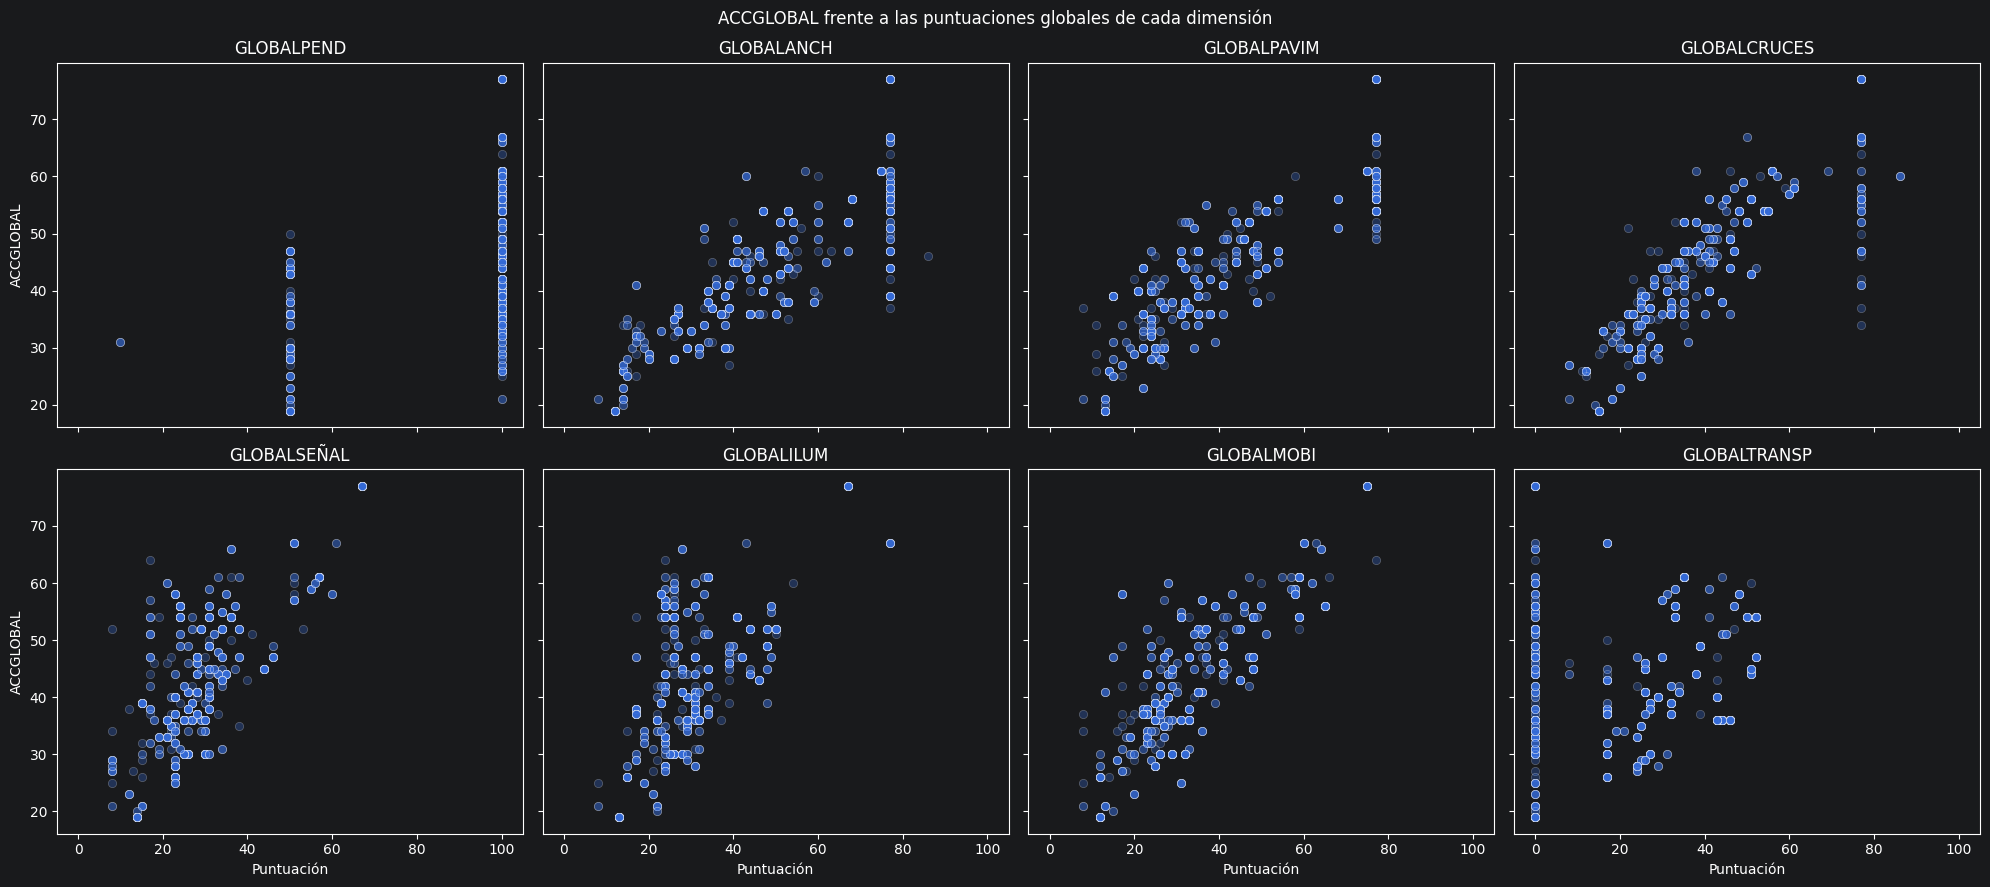

In [31]:
# Scatter plot of ACCGLOBAL against every GLOBAL<DIMENSION> column
global_dimension_columns = [info["global_column"] for info in dimensions_dict.values()]
fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharex=True, sharey=True)
for ax, column in zip(axes.ravel(), global_dimension_columns):
    sns.scatterplot(data=df_alb_streets_cleaned, x=column, y='ACCGLOBAL', alpha=0.3, ax=ax)
    ax.set(title=column, xlabel='Puntuación', ylabel='ACCGLOBAL')
fig.suptitle('ACCGLOBAL frente a las puntuaciones globales de cada dimensión')
plt.tight_layout()
plt.show()


In [32]:
# Summary statistics of the scores of every dimension and diversity type (min, quartiles, max...)
score_columns = [col for info in dimensions_dict.values() for col in info["columns"]]
display(df_alb_streets_cleaned[score_columns].describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
PENDIENTESR,916.0,87.70,21.82,10.0,100.00,100.0,100.0,100.0
PENDIENTEMR,916.0,87.70,21.82,10.0,100.00,100.0,100.0,100.0
PENDIENTEDV,916.0,87.70,21.82,10.0,100.00,100.0,100.0,100.0
PENDIENTEHA,916.0,87.70,21.82,10.0,100.00,100.0,100.0,100.0
PENDIENTEDI,916.0,87.70,21.82,10.0,100.00,100.0,100.0,100.0
ANCHURASR,916.0,43.11,24.45,9.0,27.00,36.0,63.0,90.0
ANCHURAMR,916.0,56.79,24.31,10.0,41.00,52.0,82.0,103.0
ANCHURADV,916.0,44.68,20.70,8.0,34.00,42.0,60.0,85.0
ANCHURAHA,916.0,57.73,19.25,9.0,45.00,63.0,81.0,90.0
ANCHURADI,916.0,35.92,13.73,6.0,24.00,36.0,48.0,60.0


Observamos que pendiente solo toma 3 valores distintos. Lo analizamos

In [33]:
# Show different values for PENDIENTE, per diversity
display(
    df_alb_streets_cleaned[dimensions_dict["PENDIENTE"]["columns"]]
    .apply(pd.Series.value_counts)
    .fillna(0)
    .astype(int)
)

,PENDIENTESR,PENDIENTEMR,PENDIENTEDV,PENDIENTEHA,PENDIENTEDI
100,693,693,693,693,693
50,220,220,220,220,220
10,3,3,3,3,3


Solo toma 3 valores diferentes (10, 50 o 100), y no parece distinguir entre diversidad.

También podemos observar que la variable TRANSP tiene bastantes ceros, y es la única variable que tiene 0 como valor.

##### Valores inusuales en las puntuaciones

Vamos a comprobar si, además de TRANSP, hay otras columnas de puntuación (ACCGLOBAL, las GLOBAL y las puntuaciones por dimensión y tipo de diversidad) con valores inusuales: ceros, valores negativos, o valores por encima de 100 (las puntuaciones deberían estar entre 0 y 100). Se muestran solo las columnas que tienen alguno.

In [34]:
# Look for scores with unusual values: zeros, negative values or values above 100 (the scores go from 0 to 100)
numeric_columns = ["ACCGLOBAL"] + [col for col in df_alb_streets_cleaned.columns if col.startswith("GLOBAL")] + score_columns
numeric_scores = df_alb_streets_cleaned[numeric_columns]
unusual_values = pd.DataFrame({"zeros": (numeric_scores == 0).sum(), "negative": (numeric_scores < 0).sum(), "above 100": (numeric_scores > 100).sum()})
display(unusual_values[(unusual_values > 0).any(axis=1)])


,zeros,negative,above 100
GLOBALTRANSP,323,0,0
ANCHURAMR,0,0,1
CRUCESMR,0,0,4
TRANSPSR,323,0,0
TRANSPMR,323,0,0
TRANSPDV,323,0,0
TRANSPHA,323,0,0
TRANSPDI,323,0,0


##### Los ceros de TRANSP

Observamos que hay una cantidad grande de puntuaciones con 0 en la dimensión TRANSPORTE (TRANS...). ¿Podría ser que el 0 se tratase como "no computar en el global"?

Vamos a comparar las calles que no coinciden con las que tienen `GLOBALTRANSP` igual a 0, y calculamos de nuevo la media dejando fuera esos ceros, y comprobamos si la suma global tiene diferencia con la media.

In [35]:
# Compare the mismatches of the previous mean with the streets that have GLOBALTRANSP == 0
columns = ["GLOBALPEND", "GLOBALANCH", "GLOBALPAVIM", "GLOBALCRUCES", "GLOBALSEÑAL", "GLOBALILUM", "GLOBALMOBI", "GLOBALTRANSP"]
scores = df_alb_streets_cleaned[columns]
mismatch = scores.mean(axis=1).round() != df_alb_streets_cleaned["ACCGLOBAL"]
display(pd.crosstab(df_alb_streets_cleaned["GLOBALTRANSP"] == 0, mismatch, rownames=["GLOBALTRANSP == 0"], colnames=["Mismatch with ACCGLOBAL"]))

# Mean leaving out the GLOBALTRANSP zeros
mismatch_without_zeros = scores.where(scores > 0).mean(axis=1).round() != df_alb_streets_cleaned["ACCGLOBAL"]
print(f"Mismatch found in ACCGLOBAL leaving out the TRANSP zeros: {mismatch_without_zeros.sum()} rows")


Mismatch with ACCGLOBAL,False,True
GLOBALTRANSP == 0,,
False,530,63
True,0,323


Mismatch found in ACCGLOBAL leaving out the TRANSP zeros: 97 rows


##### Calles que siguen sin coincidir

Al dejar fuera los ceros de TRANSP, las calles sin coincidencia bajan considerablemente, pero todavía quedan algunas (63 de 593). Vamos a ver cuáles son, y cuánto se alejan de `ACCGLOBAL` (mostrando la media sin redondear).

In [36]:
# Streets that still do not match leaving out the TRANSP zeros: exact mean (without rounding) against ACCGLOBAL
remaining = df_alb_streets_cleaned.loc[mismatch_without_zeros, ["REFER", "ACCGLOBAL"]].assign(mean=scores.where(scores > 0).mean(axis=1).round(2))
remaining["difference"] = (remaining["mean"] - remaining["ACCGLOBAL"]).round(2)
print(f"Streets without a match: {len(remaining)}. Maximum absolute difference: {remaining['difference'].abs().max()}")
display(remaining.sort_values("difference", key=abs, ascending=False).head(10))


Streets without a match: 97. Maximum absolute difference: 0.75


,REFER,ACCGLOBAL,mean,difference
20,CÑ1,42,41.25,-0.75
21,CÑ20,42,41.25,-0.75
51,CÑ32,42,41.25,-0.75
74,CÑ55,42,41.25,-0.75
76,CÑ57,42,41.25,-0.75
77,CÑ58,42,41.25,-0.75
164,ES8,40,39.29,-0.71
340,LL15,37,36.29,-0.71
335,LL10,25,24.29,-0.71
701,ST23,34,33.29,-0.71


##### Media con las puntuaciones originales

Las diferencias son pequeñas (menores de 1 punto), pero siguen existiendo. Las columnas GLOBAL<DIMENSION> son enteros, es decir, ya están redondeadas, y su media arrastra ese redondeo. Probamos a calcular la media con las puntuaciones originales de cada dimensión y tipo de diversidad (las 40 columnas), dejando fuera igualmente los ceros de TRANSP.

In [37]:
# Mean of the original scores (the 40 columns, leaving out the TRANSP zeros) instead of the mean of the GLOBAL<DIMENSION> columns
original_scores = df_alb_streets_cleaned[[col for info in dimensions_dict.values() for col in info["columns"]]]
original_mean = original_scores.where(original_scores > 0).mean(axis=1)
print(f"Mismatch found in ACCGLOBAL with the original scores: {(original_mean.round() != df_alb_streets_cleaned['ACCGLOBAL']).sum()} rows")
print(f"Maximum absolute difference: {(original_mean - df_alb_streets_cleaned['ACCGLOBAL']).abs().max():.2f}")


Mismatch found in ACCGLOBAL with the original scores: 23 rows
Maximum absolute difference: 0.69


##### Puntuaciones por encima de 100

Vamos a comprobar si las calles con alguna puntuación por encima de 100 son de las que no coinciden con la media: primero con la media de todas las columnas GLOBAL<DIMENSION>, y después dejando fuera los ceros de TRANSP.

In [38]:
# Streets with a score above 100: do they belong to the streets whose mean does not match ACCGLOBAL?
over_100 = df_alb_streets_cleaned[score_columns] > 100
rows_over_100 = over_100.any(axis=1)
display(pd.DataFrame({
    "REFER": df_alb_streets_cleaned.loc[rows_over_100, "REFER"],
    "scores > 100": over_100[rows_over_100].apply(lambda row: ", ".join(row.index[row]), axis=1),
    "mismatch": mismatch[rows_over_100],
    "mismatch without zeros": mismatch_without_zeros[rows_over_100],
}))


,REFER,scores > 100,mismatch,mismatch without zeros
481,PS1,ANCHURAMR,False,False
866,Y10,CRUCESMR,True,False
874,Y18,CRUCESMR,True,False
885,Y29,CRUCESMR,True,False
915,Y49,CRUCESMR,True,False


##### Conclusión de la comprobación de las medias

De los resultados anteriores se puede concluir que:
* Los ceros de TRANSP explican la mayoría de las diferencias: al dejarlos fuera de la media, las calles sin coincidencia pasan de 386 a 97.
* Si en lugar de las columnas GLOBAL<DIMENSION> se usan las 40 puntuaciones originales, bajan a 23.
* Las diferencias que quedan son menores de 1 punto (máximo 0,75 con las columnas GLOBAL y 0,69 con las originales), pero algunas superan 0,5, por lo que no se explican solo redondeando la media.

Por tanto, `ACCGLOBAL` se aproxima a la media de las dimensiones sin contar TRANSP cuando vale 0, pero no se ha encontrado la fórmula exacta, o hay errores en el conjunto de datos. Comprobamos que la diferencia máxima es menor que 1:

In [39]:
# Check that ACCGLOBAL is the mean of the GLOBAL<DIMENSION> columns, leaving out the TRANSP zeros (no transport data)
columns = ["GLOBALPEND", "GLOBALANCH", "GLOBALPAVIM", "GLOBALCRUCES", "GLOBALSEÑAL", "GLOBALILUM", "GLOBALMOBI", "GLOBALTRANSP"]
scores = df_alb_streets_cleaned[columns]
max_difference_acc = (scores.where(scores > 0).mean(axis=1) - df_alb_streets_cleaned["ACCGLOBAL"]).abs().max()
display(max_difference_acc)
assert max_difference_acc < 1  


np.float64(0.75)

### Transformación de las puntuaciones

Hay 5 puntuaciones por encima de 100 (1 en ANCHURAMR y 4 en CRUCESMR). Como las puntuaciones deben estar entre 0 y 100, se limitan esos valores a 100 y se recalculan las medias de cada calle, con las fórmulas comprobadas anteriormente:
* GLOBAL<DIMENSION>: media de las 5 puntuaciones de la dimensión.
* GLOBAL<TIPO DE DIVERSIDAD>: media de las 8 dimensiones, sin contar los ceros de TRANSP.
* `ACCGLOBAL`: media de las 5 columnas GLOBAL<TIPO DE DIVERSIDAD>.

In [40]:
# Cap the scores above 100 to 100 and recalculate the GLOBAL<DIMENSION>, GLOBAL<DIVERSITY TYPE> and ACCGLOBAL means with the formulas checked above
global_columns = ["ACCGLOBAL"] + [col for col in df_alb_streets_cleaned.columns if col.startswith("GLOBAL")]
global_before = df_alb_streets_cleaned[global_columns].copy()

df_alb_streets_cleaned[score_columns] = df_alb_streets_cleaned[score_columns].clip(upper=100)
for info in dimensions_dict.values():
    df_alb_streets_cleaned[info["global_column"]] = df_alb_streets_cleaned[info["columns"]].mean(axis=1).round().astype(int)
diversity_columns = []
for suffix in ["SR", "MR", "DV", "HA", "DI"]:
    scores = df_alb_streets_cleaned[[col for info in dimensions_dict.values() for col in info["columns"] if col.endswith(suffix)]]
    df_alb_streets_cleaned[f"GLOBAL{suffix}"] = scores.where(scores > 0).mean(axis=1).round().astype(int)  # TRANSP zeros are left out
    diversity_columns.append(f"GLOBAL{suffix}")
df_alb_streets_cleaned["ACCGLOBAL"] = df_alb_streets_cleaned[diversity_columns].mean(axis=1).round().astype(int)

# Show the values that have changed
changed = df_alb_streets_cleaned[global_columns] != global_before
print(f"Maximum score after the transformation: {df_alb_streets_cleaned[score_columns].max().max()}")
print(f"ACCGLOBAL values changed: {changed['ACCGLOBAL'].sum()}")
display(pd.concat({"before": global_before, "after": df_alb_streets_cleaned[global_columns]}, axis=1)
        .set_axis(df_alb_streets_cleaned["REFER"])
        .loc[changed.any(axis=1).values, [(when, col) for when in ("before", "after") for col in changed.columns[changed.any()]]])


Maximum score after the transformation: 100
ACCGLOBAL values changed: 0


before                            after                      
      GLOBALANCH GLOBALCRUCES GLOBALMR GLOBALANCH GLOBALCRUCES GLOBALMR
REFER                                                                  
PS1           86           77       48         85           77       48
Y10           77           86       72         77           85       71
Y18           77           86       72         77           85       71
Y29           77           86       72         77           85       71
Y49           77           86       72         77           85       71

### Análisis comparativo por dimensión y tipo de diversidad

Vamos a realizar un análisis comparativo de las puntuaciones por dimensión, y por tipo de diversidad.

Los ceros de TRANSP, que indican que no hay datos, no se tienen en cuenta en las medias.

,SR,MR,DV,HA,DI,Global
PENDIENTE,87.70,87.70,87.70,87.70,87.70,87.70
ANCHURA,43.11,56.79,44.68,57.73,35.92,47.61
PAVIMENTO,44.45,43.35,35.76,51.57,31.56,41.32
CRUCES,37.43,48.52,30.00,49.91,28.90,38.93
SEÑALIZ,32.78,37.07,20.32,36.36,19.53,29.26
ILUMIN,34.97,33.25,21.93,39.38,22.70,30.52
MOBILIAR,32.97,39.64,28.08,45.11,26.50,34.48
TRANSP,30.12,40.05,30.36,40.89,24.44,33.10
Total,43.55,48.68,37.70,51.55,35.17,43.32


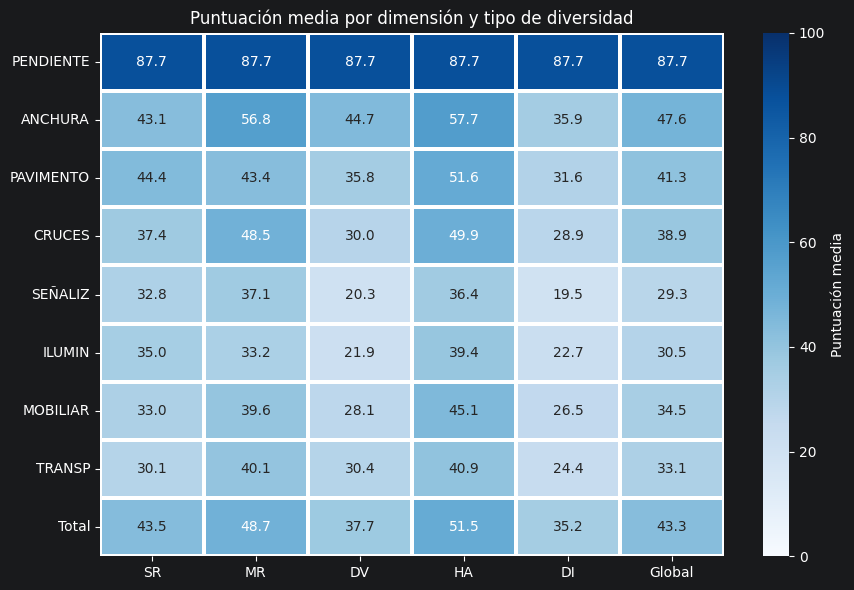

In [41]:
# Mean score per dimension (rows) and diversity type (columns), with the totals: the GLOBAL<DIVERSITY TYPE> columns for the last row
# and the GLOBAL<DIMENSION> columns for the last column (the TRANSP zeros, which mean no data, are left out of the means)
dimension_names = list(dimensions_dict) + ['Total']
score_panels = {suffix: [f'{dimension}{suffix}' for dimension in dimensions_dict] + [f'GLOBAL{suffix}'] for suffix in ['SR', 'MR', 'DV', 'HA', 'DI']}
score_panels['Global'] = [info["global_column"] for info in dimensions_dict.values()] + ['ACCGLOBAL']

mean_score = pd.DataFrame({panel: [df_alb_streets_cleaned[col].where(df_alb_streets_cleaned[col] > 0).mean() for col in columns]
                           for panel, columns in score_panels.items()}, index=dimension_names)
display(mean_score.round(2))

plt.figure(figsize=(9, 6))
sns.heatmap(mean_score, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100, linewidths=1.5, linecolor='white',
            cbar_kws={'label': 'Puntuación media'})
plt.title('Puntuación media por dimensión y tipo de diversidad')
plt.tight_layout()
plt.show()


Comprobamos que la categoría mejor puntuada, con bastante diferencia es la de PENDIENTE, con un 87,7% de puntuación de accesibilidad. ¿Podría deberse a que Albacete sea una ciudad principalmente plana, y el diseño de sus calles no añada pendientes? Al ser una puntuación tan homogénea no solo en el global, sino en cada diversidad, resulta un tanto peculiar.

Por otro lado, el resto de categorías tienen un suspenso (menor al 50% de puntuación), exceptuando el pavimento, con 51,6%, en la hipoacusia).

La categoría mejor puntuada (después de la PENDIENTE, evidentemente), es la de ANCHURA, con un 47,6%; luego PAVIMENTO, con un 41,3%, con puntuaciones bajas en visión reducida o cognitiva, y CRUCES, con un 38,9%, destacando negativamente en las mismas diversidades.

La peor categoría parece ser la señalización (un 29,3% de media), destacando negativamente en categorías como diversidad intelectual o de visión; así como la iluminación (un 30,5% de media), destacando negativamente en las mismas categorías.

En cuanto a las diversidades, la categoría con mejor puntuación es la hipoacusia, con un 51,5%, seguida de cerca de la movilidad reducida, con un 48,7%, o los 43,5% de silla de ruedas. 

Las diversidades peor paradas son la de visión (37,7%) o la intelectual (35,2%).

## Conclusiones

**Estructura y limpieza**
* El archivo (tabla `zz_gis_v`) tiene 916 filas, una por calle, y 95 columnas. No hay valores nulos ni filas duplicadas.
* Se han eliminado las 34 columnas de fotos y enlaces a Google Drive (las que empiezan por F, incluidas FICHA y FICPRESUP) y la columna MUNICIPIO (porque todas las calles son de Albacete). Se dejaron un total de 60 columnas.
* TIPOLACT y PROPACT se han transformado a categorías sin orden; REFER y NOMBRE se mantienen como texto.

**Variables categóricas y presupuesto**
* El 71,9% de las calles tiene tráfico diferenciado, seguido de peatonal (16,8%) y plataforma (6,1%). Hay 8 tipologías en total, y las dos categorías en obras son residuales.
* Hay 5 tipos de propuesta de actuación: las mejoras en vía existente suman un 83,3% (56,8% en tráfico diferenciado), los cambios de tipología un 16,5% y las calles en obras sin presupuesto un 0,2%.
* El presupuesto es asimétrico a la derecha: mediana de 123.000 € y media de 268.468 €. El 75% de las calles está por debajo de 271.000 €. La Avenida Eleazar Huerta destaca con 31.438.000 € (un 12,8% del presupuesto total).

**Puntuaciones de accesibilidad**
* Hay 8 dimensiones (PENDIENTE, ANCHURA, PAVIMENTO, CRUCES, SEÑALIZ, ILUMIN, MOBILIAR y TRANSP, esta última solo presente en este conjunto de datos de Albacete) y 5 tipos de diversidad (SR, MR, DV, HA y DI), es decir, un total de 40 columnas de puntuación. Además, hay 8 columnas GLOBAL por dimensión, 5 por tipo de diversidad y ACCGLOBAL (que es la media global de las puntuaciones individuales).
* Las puntuaciones van de 0 a 100, con 5 valores por encima de 100 (máximo de 103: 1 en ANCHURAMR y 4 en CRUCESMR), que se han limitado a 100 por coherencia. No hay valores negativos, y cada columna tiene múltiples valores distintos.
* TRANSP es la única dimensión con ceros: 323 calles (35,3%) tienen un 0 en las 5 columnas de TRANSP, y parece indicar que no hay datos de transporte. Estos ceros se dejan fuera de las medias de GLOBAL, por lo que parece una variable que solo tiene sentido cuando tiene datos.
* PENDIENTE solo toma 3 valores (10, 50 y 100) y es idéntica en los 5 tipos de diversidad. El 75,7% de las calles tiene un 100.

**Cálculo de las columnas GLOBAL y ACCGLOBAL**
* Las columnas GLOBAL<DIMENSION> son la media redondeada de las 5 puntuaciones de la dimensión.
* Las columnas GLOBAL<TIPO DE DIVERSIDAD> son la media redondeada de las 8 dimensiones, sin contar los ceros de TRANSP.
* ACCGLOBAL es la media redondeada de las 5 columnas GLOBAL<TIPO DE DIVERSIDAD>.
* La media de las 8 columnas GLOBAL<DIMENSION> es aproximadamente ACCGLOBAL: no coincide en 386 calles, 97 si se dejan fuera los ceros de TRANSP, y 23 si se usan las 40 puntuaciones originales. Las diferencias son menores de 1 punto (máximo de 0,75). Podría ser interesante recalcular las medias, para tener coherencia, si se van a utilizar en el futuro.

**Comparativa por dimensión y tipo de diversidad**
* La dimensión mejor valorada, con bastante diferencia, es PENDIENTE (87,7%). Después están ANCHURA (47,6%), PAVIMENTO (41,3%), CRUCES (38,9%), MOBILIAR (34,5%) y TRANSP (33,1%). Las peores son ILUMIN (30,5%) y SEÑALIZ (29,3%).
* Solo 3 combinaciones, además de PENDIENTE, superan el 50%: ANCHURA en movilidad reducida (56,8%) e hipoacusia (57,7%), y PAVIMENTO en hipoacusia (51,6%).
* Por tipo de diversidad, la mejor puntuación es la de hipoacusia (51,5%), seguida de movilidad reducida (48,7%) y silla de ruedas (43,5%). Las peores son visual (37,7%) y cognitiva (35,2%).
* Visual y cognitiva son también las peores en SEÑALIZ (20,3% y 19,5%), ILUMIN (21,9% y 22,7%), CRUCES (30,0% y 28,9%) y PAVIMENTO (35,8% y 31,6%).

**Implicaciones**
* Las columnas GLOBAL y ACCGLOBAL son variables derivadas (medias) de las 40 puntuaciones, por lo que no aportan información nueva.
* Hay que decidir cómo tratar los ceros de TRANSP, que parecen datos ausentes y no una puntuación real.
* PENDIENTE no discrimina entre calles ni entre tipos de diversidad.

## Guardado del conjunto de datos limpio

Vamos a realizar el guardado del conjunto de datos limpio, en la tabla /data/interim.

In [42]:
# Save dataset in the data/interim/algeciras
INTERIM_ALBACETE_DIR.mkdir(parents=True, exist_ok=True)
df_alb_streets_cleaned.to_csv(INTERIM_ALBACETE_DIR / "albacete_streets_cleaned.csv", index=False)

## Dudas y preguntas pendientes

Para el tutor o los autores de los datos:
1. ¿Cómo se asigna cada puntuación? ¿Hay algún sitio donde se pueda consultar el criterio?
2. ¿Hay algún criterio para elegir entre mejorar la vía y cambiar la tipología?
3. ¿Por qué la puntuación de una calle es igual en todo su recorrido? ¿Cómo se ha realizado la inspección, en un punto específico o aleatorio de la calle, o en varios?

## Siguientes pasos

* Analizar las relaciones entre variables: presupuesto frente a puntuaciones/clases, tipología frente a clase y propuesta...
* Analizar si hay calles que tienen el nombre repetido (o una parte de él)